In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(exist_ok=True)

In [10]:
price = pd.read_csv(RAW / "aemo_vic_hourly_price_demand.csv", parse_dates=["hour_end"])
weather = pd.read_csv(RAW / "weather_melbourne_hourly.csv", parse_dates=["time"])
print(price.shape, weather.shape)

(16056, 7) (50232, 7)


In [11]:
price = price.rename(columns={
    "rrp_mean": "price_mwh",
    "rrp_max": "price_max_mwh",
    "rrp_min": "price_min_mwh",
    "rrp_per_kwh": "price_kwh",
    "demand_mean": "demand_mw",
}).drop(columns=["n_intervals"])

weather = weather.rename(columns={
    "time": "hour_end",
    "temperature_2m": "temp_c",
    "wind_speed_10m": "wind_10m",
    "wind_speed_100m": "wind_100m",
    "shortwave_radiation": "solar_wm2",
    "direct_radiation": "direct_wm2",
    "diffuse_radiation": "diffuse_wm2",
})

master = price.merge(weather, on="hour_end", how="inner")
master = master.sort_values("hour_end").reset_index(drop=True)
master.head()

,hour_end,price_mwh,price_max_mwh,price_min_mwh,demand_mw,price_kwh,temp_c,wind_10m,wind_100m,solar_wm2,direct_wm2,diffuse_wm2
0,2024-12-01 01:00:00,92.367500,103.02,83.66,3996.239167,0.092368,19.2,5.35,9.24,0.0,0.0,0.0
1,2024-12-01 02:00:00,93.852500,100.36,79.22,3749.807500,0.093853,18.9,5.26,9.19,0.0,0.0,0.0
2,2024-12-01 03:00:00,83.407500,93.32,73.12,3534.593333,0.083407,18.8,5.11,8.87,0.0,0.0,0.0
3,2024-12-01 04:00:00,74.026667,83.66,65.93,3463.525000,0.074027,18.8,5.11,8.86,0.0,0.0,0.0
4,2024-12-01 05:00:00,77.342500,93.58,61.16,3522.304167,0.077342,18.3,5.25,8.97,0.0,0.0,0.0


In [12]:
start, end = master["hour_end"].min(), master["hour_end"].max()
expected_rows = int((end - start) / pd.Timedelta(hours=1)) + 1

print("Rows:", len(master), "| expected:", expected_rows)
print("From", start, "to", end)
print("Missing values:", int(master.isna().sum().sum()))
print("Duplicate hours:", int(master["hour_end"].duplicated().sum()))
print("Negative-price hours:", int((master["price_mwh"] < 0).sum()))
print("Hours above $1,000/MWh:", int((master["price_mwh"] > 1000).sum()))

assert len(master) == expected_rows, "Hours are missing"
assert master.isna().sum().sum() == 0, "There are blank cells"
assert not master["hour_end"].duplicated().any(), "Duplicate hours"
print("All checks passed")

master.describe().round(2).T

Rows: 15911 | expected: 15911
From 2024-12-01 01:00:00 to 2026-09-24 23:00:00
Missing values: 0
Duplicate hours: 0
Negative-price hours: 3606
Hours above $1,000/MWh: 18
All checks passed


,count,mean,min,25%,50%,75%,max,std
hour_end,15911,2025-10-28 12:00:00,2024-12-01 01:00:00,2025-05-15 18:30:00,2025-10-28 12:00:00,2026-04-12 05:30:00,2026-09-24 23:00:00,NaN
price_mwh,15911.0,66.3,-284.42,3.16,54.11,104.07,13911.69,244.8
price_max_mwh,15911.0,93.59,-161.0,12.0,74.7,125.23,19069.69,379.21
price_min_mwh,15911.0,43.02,-1000.0,-4.75,24.0,86.0,10743.99,142.61
demand_mw,15911.0,4994.81,1266.76,4212.31,4885.38,5715.54,10466.43,1207.56
price_kwh,15911.0,0.07,-0.28,0.0,0.05,0.1,13.91,0.24
temp_c,15911.0,15.49,1.7,11.4,14.7,18.8,42.1,6.02
wind_10m,15911.0,3.71,0.0,2.05,3.45,5.07,13.58,2.01
wind_100m,15911.0,5.98,0.05,3.65,5.81,8.02,19.78,3.1
solar_wm2,15911.0,179.76,0.0,0.0,5.0,308.0,1099.0,265.28


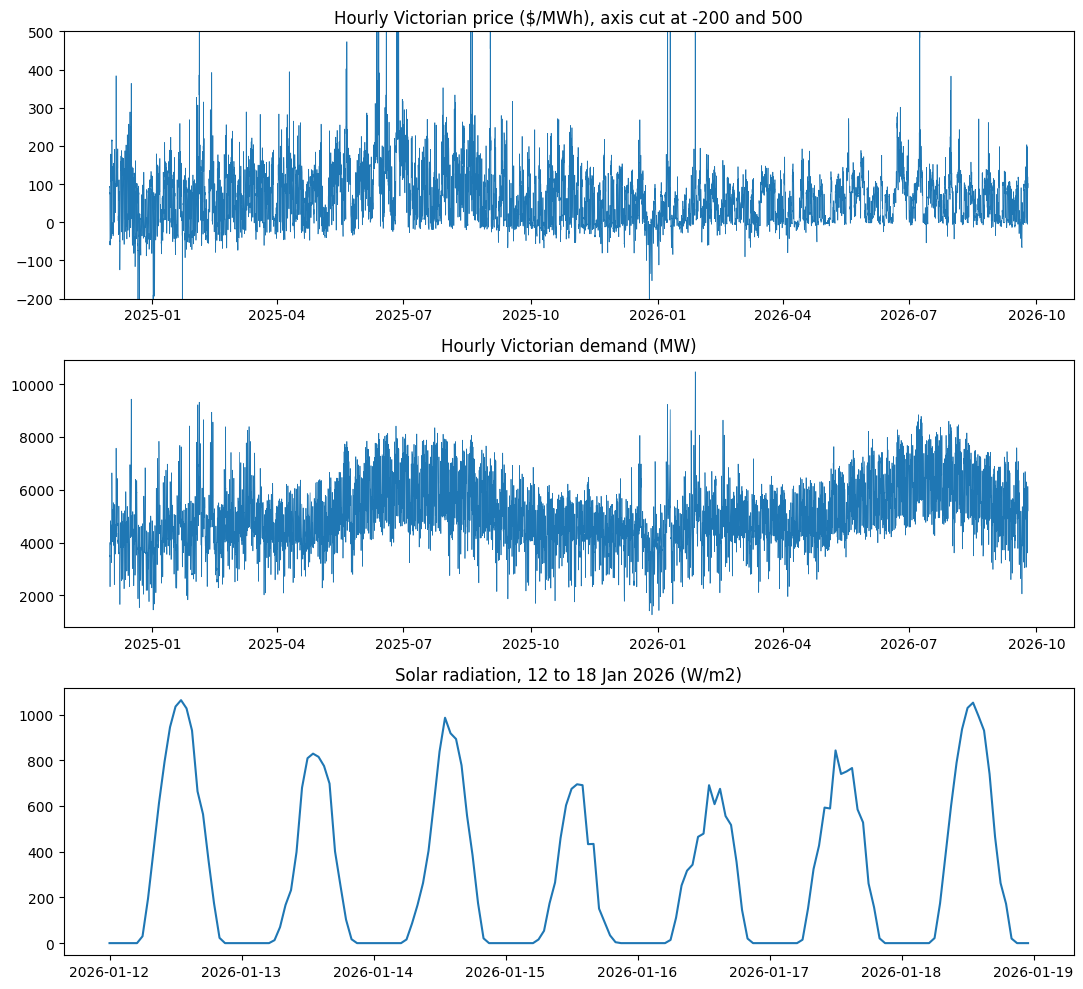

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10))

axes[0].plot(master["hour_end"], master["price_mwh"], linewidth=0.5)
axes[0].set_ylim(-200, 500)
axes[0].set_title("Hourly Victorian price ($/MWh), axis cut at -200 and 500")

axes[1].plot(master["hour_end"], master["demand_mw"], linewidth=0.5)
axes[1].set_title("Hourly Victorian demand (MW)")

week = master[(master["hour_end"] >= "2026-01-12") & (master["hour_end"] < "2026-01-19")]
axes[2].plot(week["hour_end"], week["solar_wm2"])
axes[2].set_title("Solar radiation, 12 to 18 Jan 2026 (W/m2)")

plt.tight_layout()
plt.show()

In [14]:
master.to_csv(PROCESSED / "master_hourly.csv", index=False)
print(master.shape)

(15911, 12)


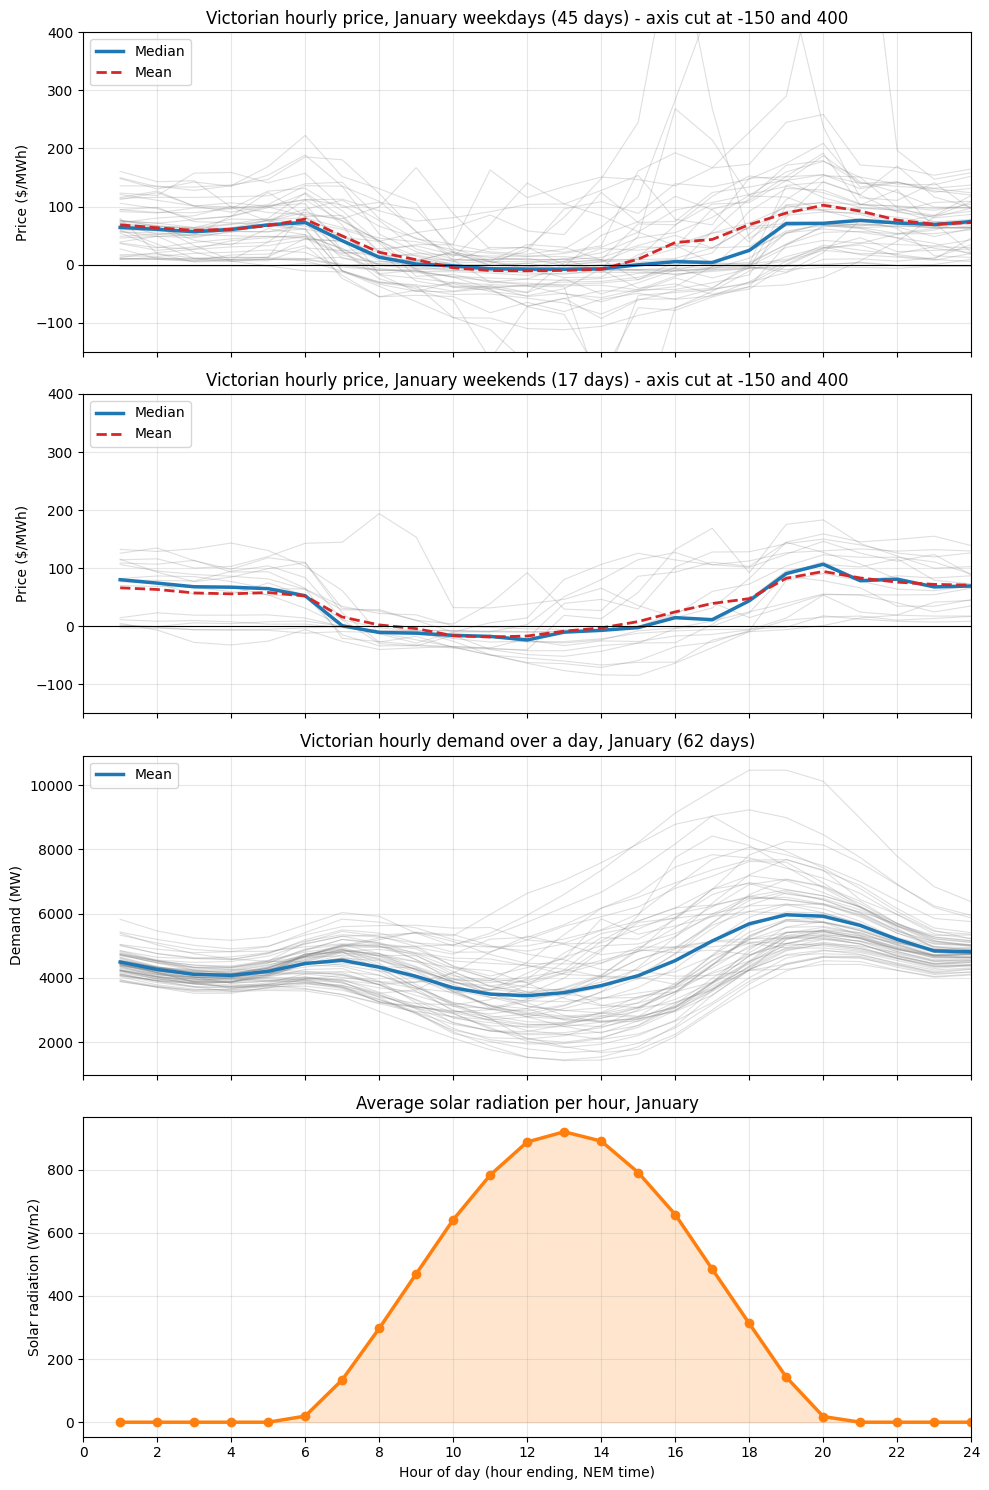

In [15]:
# Prepare January data. "start" is the start of each hour, so the 00:00 hour-ending
# row is counted on the correct day. "hour" is hour-ending, 1 to 24.
m = master.copy()
m["start"] = m["hour_end"] - pd.Timedelta(hours=1)
m["date"] = m["start"].dt.date
m["hour"] = m["start"].dt.hour + 1

jan = m[m["start"].dt.month == 1].copy()
jan["weekend"] = jan["start"].dt.dayofweek >= 5

# One row per day, one column per hour
price_wd = jan[~jan["weekend"]].pivot(index="date", columns="hour", values="price_mwh")
price_we = jan[jan["weekend"]].pivot(index="date", columns="hour", values="price_mwh")
demand = jan.pivot(index="date", columns="hour", values="demand_mw")
solar = jan.pivot(index="date", columns="hour", values="solar_wm2")

fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharex=True)

# Plot 1a and 1b: price on weekdays and weekends
for ax, table, title in [
    (axes[0], price_wd, f"Victorian hourly price, January weekdays ({len(price_wd)} days)"),
    (axes[1], price_we, f"Victorian hourly price, January weekends ({len(price_we)} days)"),
]:
    for _, day in table.iterrows():
        ax.plot(day.index, day.values, color="grey", alpha=0.25, linewidth=0.8)
    ax.plot(table.columns, table.median(), color="tab:blue", linewidth=2.5, label="Median")
    ax.plot(table.columns, table.mean(), color="tab:red", linewidth=2, linestyle="--", label="Mean")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-150, 400)
    ax.set_ylabel("Price ($/MWh)")
    ax.set_title(title + " - axis cut at -150 and 400")
    ax.legend(loc="upper left")

# Plot 2: demand over a day
for _, day in demand.iterrows():
    axes[2].plot(day.index, day.values, color="grey", alpha=0.25, linewidth=0.8)
axes[2].plot(demand.columns, demand.mean(), color="tab:blue", linewidth=2.5, label="Mean")
axes[2].set_ylabel("Demand (MW)")
axes[2].set_title(f"Victorian hourly demand over a day, January ({len(demand)} days)")
axes[2].legend(loc="upper left")

# Plot 3: average solar radiation per hour
axes[3].plot(solar.columns, solar.mean(), color="tab:orange", linewidth=2.5, marker="o")
axes[3].fill_between(solar.columns, solar.mean(), color="tab:orange", alpha=0.2)
axes[3].set_ylabel("Solar radiation (W/m2)")
axes[3].set_title("Average solar radiation per hour, January")

# Same 0 to 24 hour scale on every plot
axes[3].set_xlim(0, 24)
axes[3].set_xticks(range(0, 25, 2))
axes[3].set_xlabel("Hour of day (hour ending, NEM time)")
for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()